In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns

In [26]:
!pip install -q kagglehub

In [27]:
import kagglehub

path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

print(path)

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
/kaggle/input/microsoft-catsvsdogs-dataset


In [31]:
dataset_path = "/kaggle/input/microsoft-catsvsdogs-dataset/PetImages"

categories = ["Cat", "Dog"]

data = []
labels = []

IMG_SIZE = 64

for category in categories:

    folder = os.path.join(dataset_path, category)

    label = categories.index(category)

    count = 0

    for img_name in os.listdir(folder):

        try:
            img_path = os.path.join(folder, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            data.append(img.flatten())

            labels.append(label)

            count += 1

            # Use only 500 images from each class
            if count == 500:
                break

        except:
            continue

In [32]:
X = np.array(data)

y = np.array(labels)

print(X.shape)

print(y.shape)

(1000, 4096)
(1000,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
model = SVC(kernel="linear")

model.fit(X_train, y_train)

SVC(kernel='linear')

In [35]:
y_pred = model.predict(X_test)

In [36]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.505


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.49      0.49        96
           1       0.52      0.52      0.52       104

    accuracy                           0.51       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.51      0.51      0.51       200



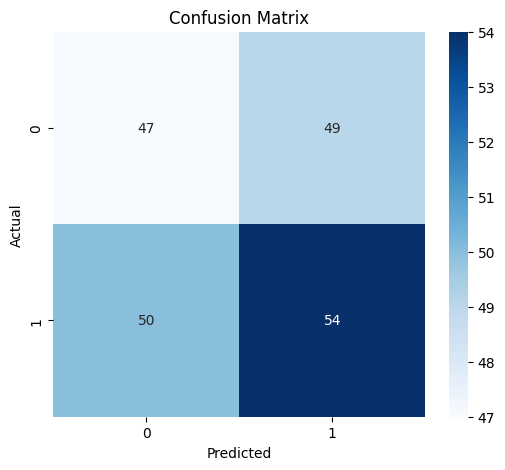

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

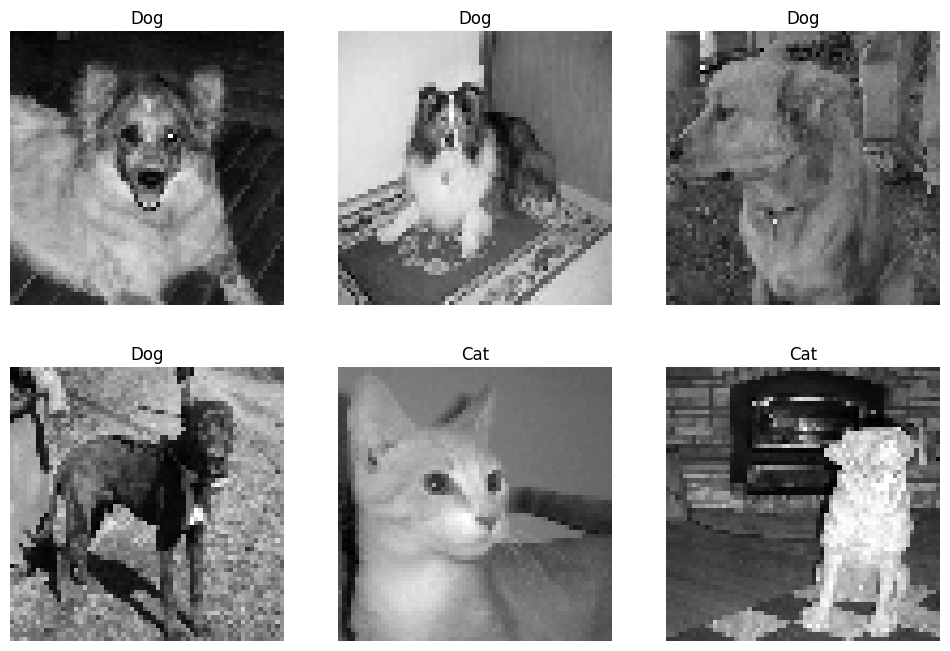

In [39]:
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[i].reshape(64,64), cmap="gray")

    prediction = model.predict([X_test[i]])[0]

    if prediction == 0:
        plt.title("Cat")
    else:
        plt.title("Dog")

    plt.axis("off")

plt.show()